<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 7
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consigna

Usando el archivo ecg.mat que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptadas a continuación. Diseñe y aplique los filtros digitales necesarios para mitigar las siguientes fuentes de contaminación:

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).
- Ruido muscular (Alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

**Ayuda:** Los detalles de cómo acceder a ecg.mat los pueden encontrar en lectura_sigs.py

## *Archivo ECG.mat*

*(variables)*

- ***ecg_lead***: Registro de ECG muestreado a *fs* = 1 kHz durante una prueba de esfuerzo
- ***qrs_pattern1***: Complejo de ondas QRS normal
- ***heartbeat_pattern1***: Latido normal
- ***heartbeat_pattern2***: Latido de origen ventricular
- ***qrs_detections***: vector con las localizaciones (en # de muestras) donde ocurren los latidos


**Se pide:**

**a)** Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a suavidad de los trazos y nivel isoeléctrico nulo.

**Ayuda:** Utilice los resultados del ancho de banda estimado del ECG **en la Tarea Semanal 5**. Tome como referencia las siguientes morfologías promedio para evaluar cualitativamente la efectividad de los filtros diseñados.

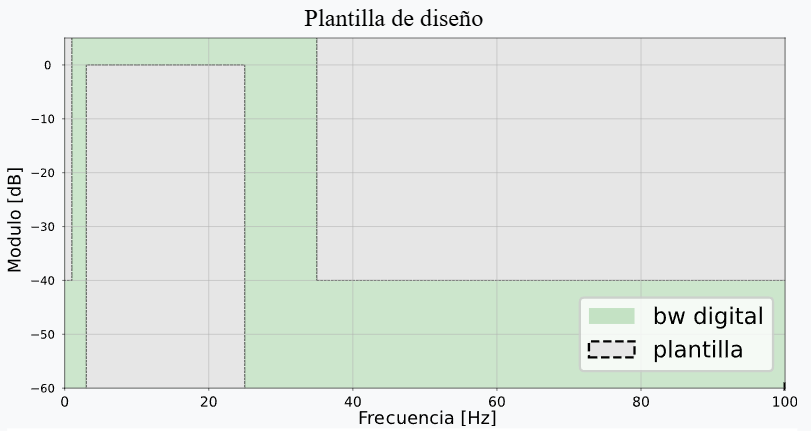
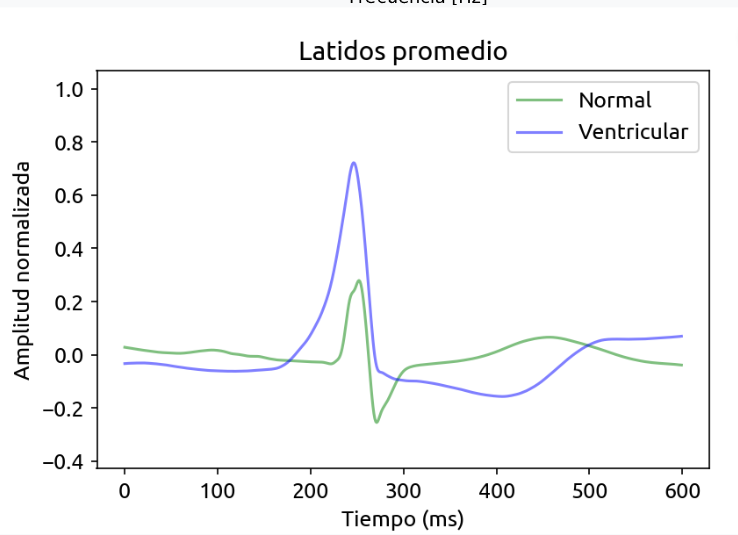
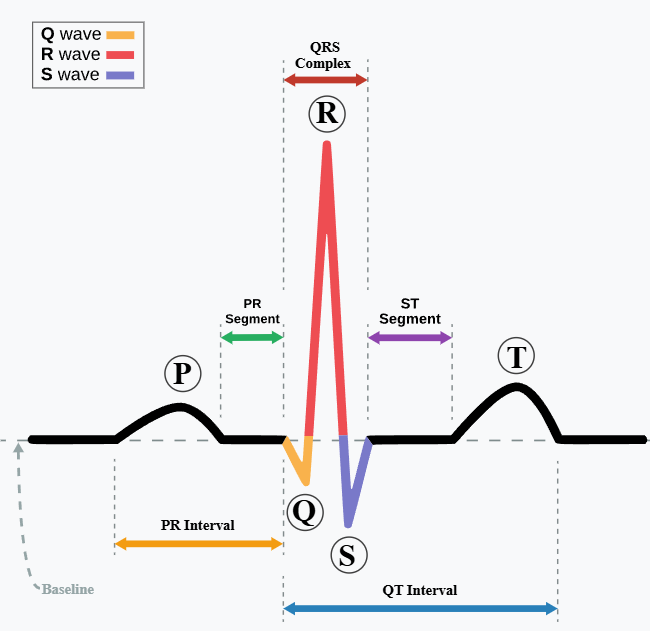


In [ ]:
#############
# Plantilla #
#############
 
nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB
 
ws1 = ?? # Hz
wp1 = ?? # Hz
wp2 = ?? # Hz
ws2 = ?? # Hz
 
# plantilla normalizada a Nyquist en dB
frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ]) / nyq_frec
gains = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])
 
# convertimos a veces para las funciones de diseño
gains = 10**(gains/20)

**b)** ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

**c)** Diseñe **al menos** dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

**Ayuda:** Para los filtros IIR adopte las aproximaciones de módulo de [máxima planicidad, Chebyshev y Cauer](). Para los FIR, utilice las metodologías de [ventanas, cuadrados mínimos]() y [Parks-Mc Clellan-Remez](). Todos implementados en [SciPy.Signal]()

**d)** Evalúe el rendimiento de los filtros que haya diseñado:

1. Verifique que filtra las señales interferentes.
2. Verifique que es inocuo en las zonas donde no hay interferentes.

**Ayuda:** Utilice el siguiente código como referencia para analizar los puntos 1 y 2). **También puede incluir otras regiones que considere de interés.**

In [ ]:
 
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure(1)
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    #plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure(2)
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    #plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

**Bonus:**

- 💎 Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

# Plantilla de diseño 


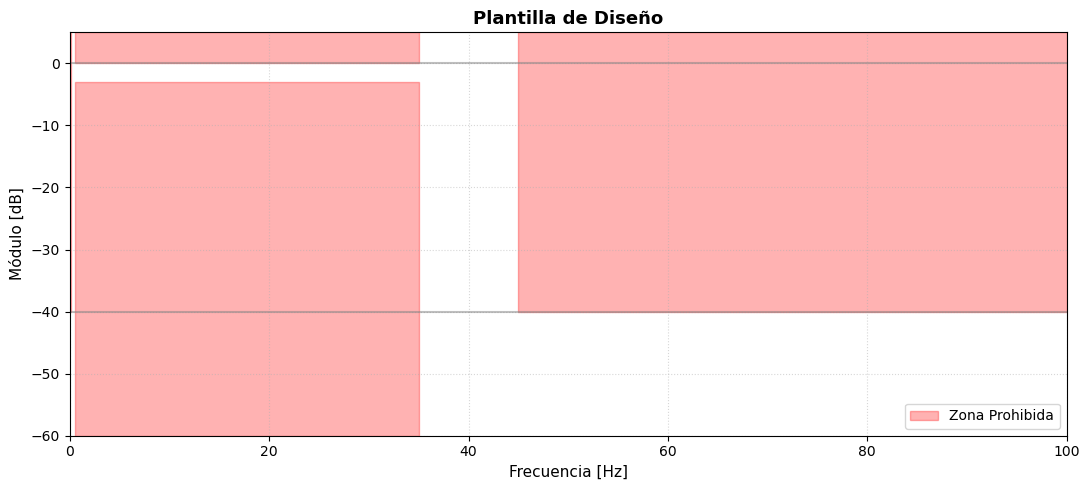

In [7]:
import matplotlib.pyplot as plt
import numpy as np

ws1 = 0.1
wp1 = 0.5
wp2 = 35
ws2 = 45

f_min, f_max = 0, 100
gain_min, gain_max = -60, 5

plt.figure(figsize=(11, 5))

# Banda de rechazo inferior (0 a ws1): Prohibido arriba de -40 dB
plt.fill_between([0, ws1], -40, gain_max, color='red', alpha=0.3, label='Zona Prohibida')

# Banda de paso (wp1 a wp2): 
# Prohibido abajo de -3 dB (tolerancia de rizado) y arriba de 0 dB
plt.fill_between([wp1, wp2], gain_min, -3, color='red', alpha=0.3)
plt.fill_between([wp1, wp2], 0, gain_max, color='red', alpha=0.3)

# Banda de rechazo superior (ws2 a 100 Hz): Prohibido arriba de -40 dB
plt.fill_between([ws2, f_max], -40, gain_max, color='red', alpha=0.3)

frecuencias = [ws1, wp1, wp2, ws2]
etiquetas = [f'ws1 = {ws1}', f'wp1 = {wp1}', f'wp2 = {wp2}', f'ws2 = {ws2}']
colores = ['darkred', 'darkgreen', 'darkgreen', 'darkred']

plt.axhline(y=-40, color='gray', linestyle='-', alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

plt.xlim(f_min, f_max)
plt.ylim(gain_min, gain_max)
plt.xlabel('Frecuencia [Hz]', fontsize=11)
plt.ylabel('Módulo [dB]', fontsize=11)
plt.title('Plantilla de Diseño', fontsize=13, fontweight='bold')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()